In [1]:
import os, sys, glob, subprocess
import torch
print("python", sys.version.split()[0], "| torch", torch.__version__, "| cuda:", torch.cuda.is_available(),
      torch.cuda.get_device_name(0) if torch.cuda.is_available() else "")
try:
    import gdown
except ImportError:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "gdown"], check=True)
    import gdown

DATA = "/kaggle/working/data"; os.makedirs(DATA, exist_ok=True)
FOLDER = "https://drive.google.com/drive/folders/1R4pOtvDEYyXtjLgVsT2RsmaORKOzoEq2"
try:
    gdown.download_folder(FOLDER, output=DATA, quiet=True, use_cookies=False, remaining_ok=True)
except Exception as e:
    print("download failed:", repr(e)[:300])
files = sorted(p for p in glob.glob(f"{DATA}/**/*", recursive=True) if os.path.isfile(p))
if not files:                                   
    files = sorted(p for p in glob.glob("/kaggle/input/**/*", recursive=True) if os.path.isfile(p))
print("files found:", len(files))
for p in files:
    size = os.path.getsize(p)
    print(f"\n{p} | {size/1e6:.2f} MB")
    if p.lower().endswith((".zip", ".gz", ".tar", ".tgz", ".pt", ".pkl", ".bin")):
        print("  compressed or binary file, not shown"); continue
    if size < 200e6:
        n, head = 0, []
        with open(p, encoding="utf-8", errors="replace") as f:
            for line in f:
                n += 1
                if n <= 5: head.append(line.rstrip("\n")[:200])
        print("  lines:", n)
        for l in head: print("  ", repr(l))

python 3.13.15 | torch 2.11.0+cu128 | cuda: True Tesla T4
files found: 3

/kaggle/working/data/en_fr_test.csv | 1.74 MB
  lines: 8598
   'en,fr'
   '"Several years ago here at TED, Peter Skillman  introduced a design challenge  called the marshmallow challenge.","Il y a plusieurs années, ici à Ted, Peter Skillman a présenté une épreuve de concepti'
   '"And the idea\'s pretty simple:  Teams of four have to build the tallest free-standing structure  out of 20 sticks of spaghetti,  one yard of tape, one yard of string  and a marshmallow.","Et l\'idée es'
   'The marshmallow has to be on top.,Le marshmallow doit être placé au sommet.'
   '"And, though it seems really simple, it\'s actually pretty hard  because it forces people  to collaborate very quickly.","Bien que cela semble vraiment simple, c\'est en fait plutôt difficile, parce que'

/kaggle/working/data/en_fr_train.csv | 48.47 MB
  lines: 232826
   'en,fr'
   '"Thank you so much, Chris. And it\'s truly a great honor to have the opp

In [2]:
import re, random, collections, subprocess, sys
import numpy as np
try:
    import sacrebleu
except ImportError:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "sacrebleu"], check=True)
    import sacrebleu

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

PUNCT = r".,!?;:\"“”()\[\]।"
TOK = re.compile(rf"[^\s{PUNCT}]+|[{PUNCT}]")
def tokenize(text): return TOK.findall(text.lower().strip())

class Vocab:
    PAD, SOS, EOS, UNK = "<pad>", "<sos>", "<eos>", "<unk>"
    def __init__(self, sentences, max_size=10000, min_freq=2):
        counts = collections.Counter(t for s in sentences for t in s)
        self.itos = [self.PAD, self.SOS, self.EOS, self.UNK]
        for tok, c in counts.most_common():
            if c < min_freq or len(self.itos) >= max_size: break
            self.itos.append(tok)
        self.stoi = {t: i for i, t in enumerate(self.itos)}
        self.pad, self.sos, self.eos, self.unk = 0, 1, 2, 3
    def __len__(self): return len(self.itos)
    def encode(self, toks, add_se=False):
        ids = [self.stoi.get(t, self.unk) for t in toks]
        return [self.sos] + ids + [self.eos] if add_se else ids
    def decode(self, ids, stop_at_eos=True):
        out = []
        for i in ids:
            if i == self.eos and stop_at_eos: break
            if i in (self.pad, self.sos): continue
            out.append(self.itos[i])
        return out

for s in ["I am hungry.", "Je n'ai pas faim, mais j'ai soif !", "मैं भूखा हूँ।"]:
    print(tokenize(s))
corpus = [tokenize(s) for s in ["the cat sat on the mat", "the dog sat on the log", "a bird flew"]]
v = Vocab(corpus, max_size=100, min_freq=2); print("vocab:", v.itos)
ids = v.encode(tokenize("the cat flew"), add_se=True); print("encode:", ids, "| decode:", v.decode(ids))
print("sacrebleu", sacrebleu.__version__, "| BLEU check:", round(sacrebleu.sentence_bleu("the cat sat on a mat", ["the cat sat on the mat"], smooth_method="none").score, 1), "(expect 53.7)")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.6/129.6 kB 5.4 MB/s eta 0:00:00
['i', 'am', 'hungry', '.']
['je', "n'ai", 'pas', 'faim', ',', 'mais', "j'ai", 'soif', '!']
['मैं', 'भूखा', 'हूँ', '।']
vocab: ['<pad>', '<sos>', '<eos>', '<unk>', 'the', 'sat', 'on']
encode: [1, 4, 3, 3, 2] | decode: ['the', '<unk>', '<unk>']
sacrebleu 2.6.0 | BLEU check: 53.7 (expect 53.7)


In [3]:
import torch.nn as nn
device = "cuda" if torch.cuda.is_available() else "cpu"

class Encoder(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden, layers, dropout, pad_id):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, emb_dim, padding_idx=pad_id)
        self.rnn = nn.LSTM(emb_dim, hidden, layers, batch_first=True, dropout=dropout if layers > 1 else 0.0)
        self.drop = nn.Dropout(dropout)
    def forward(self, src, src_len):                     
        x = self.drop(self.emb(src))
        packed = nn.utils.rnn.pack_padded_sequence(x, src_len.cpu(), batch_first=True, enforce_sorted=False)
        _, (h, c) = self.rnn(packed)                     
        return h, c                                      

class Decoder(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden, layers, dropout, pad_id):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, emb_dim, padding_idx=pad_id)
        self.rnn = nn.LSTM(emb_dim, hidden, layers, batch_first=True, dropout=dropout if layers > 1 else 0.0)
        self.out = nn.Linear(hidden, vocab_size)
        self.drop = nn.Dropout(dropout)
    def forward(self, tok, h, c):                        
        x = self.drop(self.emb(tok)).unsqueeze(1)        
        o, (h, c) = self.rnn(x, (h, c))
        return self.out(o.squeeze(1)), h, c              

class Seq2Seq(nn.Module):
    def __init__(self, enc, dec):
        super().__init__(); self.enc, self.dec = enc, dec
    def forward(self, src, src_len, tgt, tf_ratio=1.0):
        h, c = self.enc(src, src_len)
        tok, outs = tgt[:, 0], []
        for t in range(1, tgt.shape[1]):
            out, h, c = self.dec(tok, h, c)
            outs.append(out)
            tok = tgt[:, t] if random.random() < tf_ratio else out.argmax(1)
        return torch.stack(outs, dim=1)                  

V, PAD = 1000, 0
torch.manual_seed(SEED)
model = Seq2Seq(Encoder(V, 64, 128, 1, 0.0, PAD), Decoder(V, 64, 128, 1, 0.0, PAD)).to(device)
print("parameters:", sum(p.numel() for p in model.parameters()), "| expected 455656")
src = torch.randint(4, V, (8, 7), device=device); src_len = torch.tensor([7, 5, 3, 6, 7, 4, 7, 2])
for i, L in enumerate(src_len.tolist()): src[i, L:] = PAD
tgt = torch.randint(4, V, (8, 9), device=device); tgt[:, 0] = 1
logits = model(src, src_len, tgt, tf_ratio=1.0)
print("logits shape:", tuple(logits.shape), "| expected (8, 8, 1000)")

lossf = nn.CrossEntropyLoss(ignore_index=PAD); opt = torch.optim.Adam(model.parameters(), lr=3e-3)
for step in range(300):                                  
    opt.zero_grad(); loss = lossf(model(src, src_len, tgt, 1.0).reshape(-1, V), tgt[:, 1:].reshape(-1))
    loss.backward(); torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0); opt.step()
    if step in (0, 100, 200, 299): print("step", step, "loss", round(loss.item(), 4))
print("ln(V) =", round(float(np.log(V)), 3), "(loss of a random guesser)")

parameters: 455656 | expected 455656
logits shape: (8, 8, 1000) | expected (8, 8, 1000)
step 0 loss 6.919
step 100 loss 0.0142
step 200 loss 0.0049
step 299 loss 0.0026
ln(V) = 6.908 (loss of a random guesser)


In [4]:
import re, collections, pandas as pd
FILES = {"train": f"{DATA}/en_fr_train.csv", "val": f"{DATA}/en_fr_val.csv", "test": f"{DATA}/en_fr_test.csv"}
raw = {k: pd.read_csv(p) for k, p in FILES.items()}
for k, d in raw.items():
    print(k, d.shape, "| rows with a missing side:", int(d.isna().any(axis=1).sum()), "| exact duplicate pairs:", int(d.duplicated().sum()))

MARK_FR = re.compile(r"--\s*(?:Rires?|Applaudissements?|Faux sanglot|Musique|Vidéo)(?:\s+\w+)?\s*--", re.IGNORECASE)      
def clean_en(s): return re.sub(r"\s+", " ", str(s).replace("’", "'")).strip()
def clean_fr(s):
    s = MARK_FR.sub(" ", str(s)).replace("’", "'")
    return re.sub(r"\s+", " ", s).strip()
removed = collections.Counter(m.group(0) for s in raw["train"].fr.astype(str) for m in MARK_FR.finditer(s))
print("French stage directions removed (train):", sum(removed.values()), "| most common:", removed.most_common(8))
TAG = r"\((?:Laughter|Applause|Music|Video)[^)]*\)"
print("English rows with (Laughter)/(Applause)-style tags:", {k: int(d.en.astype(str).str.contains(TAG, case=False).sum()) for k, d in raw.items()})

data = {}
for k, d in raw.items():
    d = d.dropna().copy(); d["en"] = d.en.map(clean_en); d["fr"] = d.fr.map(clean_fr)
    data[k] = d[(d.en.str.len() > 0) & (d.fr.str.len() > 0)].reset_index(drop=True)
print("usable rows:", {k: len(d) for k, d in data.items()})
tr_pairs, tr_en = set(zip(data["train"].en, data["train"].fr)), set(data["train"].en)
for k in ("val", "test"):
    d = data[k]
    print(k, "| pairs also in train:", sum((e, f) in tr_pairs for e, f in zip(d.en, d.fr)), "| English sentences also in train:",
          int(d.en.isin(tr_en).sum()), "of", len(d))

PUNCT = r".,!?;:\"“”()\[\]।"
TOK = re.compile(rf"[^\s{PUNCT}]+|[{PUNCT}]")
def tok_en(t): return TOK.findall(t.lower())
def tok_fr_a(t): return TOK.findall(t.lower())                                   
def tok_fr_b(t): return TOK.findall(re.sub(r"(\w+')", r"\1 ", t.lower()))        

tr = data["train"]
len_en = np.array([len(tok_en(s)) for s in tr.en]); len_fr = np.array([len(tok_fr_b(s)) for s in tr.fr])
for name, L in (("English", len_en), ("French", len_fr)):
    print(name, "tokens per sentence: median %d | 90%% %d | 99%% %d | max %d" % (np.median(L), np.percentile(L, 90), np.percentile(L, 99), L.max()))
MAX_LEN = 50
ratio = (len_fr + 1) / (len_en + 1)
keep = (len_en >= 1) & (len_fr >= 1) & (len_en <= MAX_LEN) & (len_fr <= MAX_LEN) & (ratio <= 3) & (ratio >= 1 / 3)
print("train pairs kept: %d of %d (%.1f%%) | too long: %d | length ratio outside 1/3 to 3: %d" % (
    keep.sum(), len(tr), 100 * keep.mean(), int(((len_en > MAX_LEN) | (len_fr > MAX_LEN)).sum()), int(((ratio > 3) | (ratio < 1 / 3)).sum())))
tr_f = tr[keep].reset_index(drop=True)
worst = tr.assign(ratio=ratio).sort_values("ratio").iloc[[0, 1, -2, -1]]
for _, r in worst.iterrows(): print("  ratio %.2f | EN: %s | FR: %s" % (r.ratio, r.en[:90], r.fr[:90]))

def unk_rate(train_sents, eval_sents, max_size=10000, min_freq=2):
    counts = collections.Counter(t for s in train_sents for t in s)
    vocab = {t for t, c in counts.most_common(max_size - 4) if c >= min_freq}
    tot = sum(len(s) for s in eval_sents); unk = sum(t not in vocab for s in eval_sents for t in s)
    return len(vocab) + 4, unk / tot
va = data["val"]; rates = {}
for name, f in (("a", tok_fr_a), ("b", tok_fr_b)):
    size, u = unk_rate([f(s) for s in tr_f.fr], [f(s) for s in va.fr]); rates[name] = u
    print("French tokenization %s | vocab %5d | val <unk> rate %.4f" % (name, size, u))
size, u = unk_rate([tok_en(s) for s in tr_f.en], [tok_en(s) for s in va.en]); print("English | vocab %5d | val <unk> rate %.4f" % (size, u))
tok_fr = tok_fr_b if rates["b"] < rates["a"] else tok_fr_a
print("chosen French tokenization:", "b (split after apostrophes)" if tok_fr is tok_fr_b else "a (apostrophes kept)")

train (232825, 2) | rows with a missing side: 0 | exact duplicate pairs: 2054
val (890, 2) | rows with a missing side: 0 | exact duplicate pairs: 7
test (8597, 2) | rows with a missing side: 0 | exact duplicate pairs: 71
French stage directions removed (train): 14 | most common: [('--Rires--', 9), ('--Faux sanglot--', 2), ('--Applaudissements--', 2), ('--Rires Applaudissements--', 1)]
English rows with (Laughter)/(Applause)-style tags: {'train': 0, 'val': 0, 'test': 0}
usable rows: {'train': 232825, 'val': 890, 'test': 8597}
val | pairs also in train: 12 | English sentences also in train: 14 of 890
test | pairs also in train: 96 | English sentences also in train: 134 of 8597
English tokens per sentence: median 16 | 90% 38 | 99% 69 | max 136
French tokens per sentence: median 18 | 90% 41 | 99% 75 | max 135
train pairs kept: 220442 of 232825 (94.7%) | too long: 12320 | length ratio outside 1/3 to 3: 65
  ratio 0.13 | EN: Now, you talk straight to me, what's wrong with my films? | FR: -
 

In [5]:
import random, sacrebleu

v_en = Vocab([tok_en(s) for s in tr_f.en], max_size=10000, min_freq=2)
v_fr = Vocab([tok_fr(s) for s in tr_f.fr], max_size=10000, min_freq=2)
PAD, SOS, EOS = v_en.pad, v_en.sos, v_en.eos
assert (v_fr.pad, v_fr.sos, v_fr.eos) == (PAD, SOS, EOS)
def encode_split(d):
    return [v_en.encode(tok_en(s)) + [EOS] for s in d.en], [v_fr.encode(tok_fr(s), add_se=True) for s in d.fr]
tr_src, tr_tgt = encode_split(tr_f); va_src, va_tgt = encode_split(data["val"])
def tok_unk_rate(seqs): return sum(t == 3 for s in seqs for t in s) / sum(len(s) for s in seqs)
print("vocab sizes: EN", len(v_en), "FR", len(v_fr), "| train pairs", len(tr_src), "| val pairs", len(va_src))
print("token <unk> rate: train EN %.4f FR %.4f | val EN %.4f FR %.4f" % (tok_unk_rate(tr_src), tok_unk_rate(tr_tgt), tok_unk_rate(va_src), tok_unk_rate(va_tgt)))

def make_batches(src_ids, tgt_ids, batch_size, shuffle, rng, chunk=50):
    idx = np.arange(len(src_ids))
    if shuffle: rng.shuffle(idx)
    batches, step = [], batch_size * chunk
    for s in range(0, len(idx), step):
        part = sorted(idx[s:s + step].tolist(), key=lambda i: len(src_ids[i]))     # similar lengths together
        batches += [part[b:b + batch_size] for b in range(0, len(part), batch_size)]
    if shuffle: rng.shuffle(batches)
    return batches
def pad_batch(seqs):
    L = max(len(s) for s in seqs)
    return torch.tensor([s + [PAD] * (L - len(s)) for s in seqs], dtype=torch.long)
def get_batch(src_ids, tgt_ids, ids):
    return (pad_batch([src_ids[i] for i in ids]).to(device), torch.tensor([len(src_ids[i]) for i in ids]),
            pad_batch([tgt_ids[i] for i in ids]).to(device))

def detok_fr(tokens):
    s = re.sub(r"(\w')\s+", r"\1", " ".join(tokens))                
    s = re.sub(r"\s+([.,!?;:।)\]])", r"\1", s)                      
    return re.sub(r"([(\[])\s+", r"\1", s)

@torch.no_grad()
def greedy(model, src, src_len, max_len=60):
    model.eval()
    h, c = model.enc(src, src_len)
    tok = torch.full((src.size(0),), SOS, dtype=torch.long, device=device); outs = []
    done = torch.zeros(src.size(0), dtype=torch.bool, device=device)
    for _ in range(max_len):
        out, h, c = model.dec(tok, h, c); tok = out.argmax(1); outs.append(tok)
        done |= tok == EOS
        if done.all(): break
    return torch.stack(outs, 1).tolist()
def translate(model, src_ids, only=None, batch_size=128, max_len=60):
    order = sorted(range(len(src_ids)) if only is None else only, key=lambda i: len(src_ids[i])); hyp = {}
    for s in range(0, len(order), batch_size):
        ids = order[s:s + batch_size]
        src = pad_batch([src_ids[i] for i in ids]).to(device); sl = torch.tensor([len(src_ids[i]) for i in ids])
        for i, out in zip(ids, greedy(model, src, sl, max_len)): hyp[i] = detok_fr(v_fr.decode(out))
    return hyp
def bleu_on(model, d, src_ids, only=None):
    hyp = translate(model, src_ids, only); ids = sorted(hyp)
    return sacrebleu.corpus_bleu([hyp[i] for i in ids], [[d.fr[i] for i in ids]], lowercase=True).score, hyp

rng = np.random.default_rng(SEED)
b = make_batches(tr_src, tr_tgt, 128, True, rng)[0]; s_, sl_, t_ = get_batch(tr_src, tr_tgt, b)
print("first batch: source", tuple(s_.shape), "target", tuple(t_.shape), "| padded cells:", int((s_ == PAD).sum()), "of", s_.numel())
print("example source:", " ".join(v_en.decode(tr_src[b[0]])), "\nexample target:", detok_fr(v_fr.decode(tr_tgt[b[0]])))

vocab sizes: EN 10000 FR 10000 | train pairs 220442 | val pairs 890
token <unk> rate: train EN 0.0344 FR 0.0448 | val EN 0.0420 FR 0.0541
first batch: source (128, 23) target (128, 39) | padded cells: 78 of 2944
example source: and so , to boil it all down , simplicity is about living life with more <unk> and less pain . 
example target: pour résumer, la simplicité revient à vivre sa vie de la façon la plus amusante, avec le moins de peine possible.


In [6]:
import time, json
cfg = dict(emb=256, hidden=512, layers=2, dropout=0.3)
BS, EPOCHS, MAX_MIN, LR = 128, 10, 40, 1e-3
torch.manual_seed(SEED); random.seed(SEED); rng = np.random.default_rng(SEED)
model = Seq2Seq(Encoder(len(v_en), cfg["emb"], cfg["hidden"], cfg["layers"], cfg["dropout"], PAD),
                Decoder(len(v_fr), cfg["emb"], cfg["hidden"], cfg["layers"], cfg["dropout"], PAD)).to(device)
n_params = sum(p.numel() for p in model.parameters()); print("parameters:", n_params)
opt = torch.optim.Adam(model.parameters(), lr=LR); lossf = nn.CrossEntropyLoss(ignore_index=PAD)

def val_loss():
    model.eval(); tot, n = 0.0, 0
    with torch.no_grad():
        for ids in make_batches(va_src, va_tgt, 128, False, rng):
            src, sl, tgt = get_batch(va_src, va_tgt, ids); lg = model(src, sl, tgt, 1.0)
            tot += lossf(lg.reshape(-1, lg.size(-1)), tgt[:, 1:].reshape(-1)).item() * len(ids); n += len(ids)
    return tot / n

history, best_bleu, bad, t_start = [], -1.0, 0, time.time()
for epoch in range(EPOCHS):
    tf_ratio = max(0.5, 1.0 - 0.1 * epoch)
    model.train(); tot, nb, t0 = 0.0, 0, time.time()
    batches = make_batches(tr_src, tr_tgt, BS, True, rng)
    for bi, ids in enumerate(batches):
        src, sl, tgt = get_batch(tr_src, tr_tgt, ids)
        opt.zero_grad(set_to_none=True)
        lg = model(src, sl, tgt, tf_ratio)
        loss = lossf(lg.reshape(-1, lg.size(-1)), tgt[:, 1:].reshape(-1))
        loss.backward(); torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0); opt.step()
        tot += loss.item(); nb += 1
        if bi % 300 == 0: print(f"  epoch {epoch+1} batch {bi}/{len(batches)} loss {loss.item():.3f} | {time.time()-t0:.0f} s")
    vl = val_loss(); bl, _ = bleu_on(model, data["val"], va_src)
    history.append((epoch + 1, tf_ratio, tot / nb, vl, bl, time.time() - t0))
    print("epoch %d | tf %.1f | train loss %.3f | val loss %.3f | val BLEU %.2f | %.0f s" % history[-1])
    if bl > best_bleu:
        best_bleu, bad = bl, 0; torch.save(model.state_dict(), "/kaggle/working/s1_best.pt")
    else:
        bad += 1
        if bad >= 2: print("early stop: val BLEU did not improve for 2 epochs"); break
    if (time.time() - t_start) / 60 > MAX_MIN: print("time budget reached"); break
json.dump(history, open("/kaggle/working/s1_history.json", "w"))
model.load_state_dict(torch.load("/kaggle/working/s1_best.pt")); print("best val BLEU %.2f" % best_bleu)

parameters: 17606416
  epoch 1 batch 0/1723 loss 9.211 | 0 s
  epoch 1 batch 300/1723 loss 3.214 | 32 s
  epoch 1 batch 600/1723 loss 4.493 | 65 s
  epoch 1 batch 900/1723 loss 3.506 | 99 s
  epoch 1 batch 1200/1723 loss 3.481 | 135 s
  epoch 1 batch 1500/1723 loss 2.752 | 172 s
epoch 1 | tf 1.0 | train loss 4.083 | val loss 3.538 | val BLEU 2.47 | 201 s
  epoch 2 batch 0/1723 loss 4.524 | 0 s
  epoch 2 batch 300/1723 loss 3.632 | 39 s
  epoch 2 batch 600/1723 loss 3.955 | 77 s
  epoch 2 batch 900/1723 loss 2.759 | 115 s
  epoch 2 batch 1200/1723 loss 3.272 | 154 s
  epoch 2 batch 1500/1723 loss 3.271 | 192 s
epoch 2 | tf 0.9 | train loss 3.345 | val loss 3.237 | val BLEU 3.52 | 223 s
  epoch 3 batch 0/1723 loss 3.834 | 0 s
  epoch 3 batch 300/1723 loss 2.635 | 40 s
  epoch 3 batch 600/1723 loss 2.957 | 79 s
  epoch 3 batch 900/1723 loss 4.037 | 118 s
  epoch 3 batch 1200/1723 loss 3.414 | 158 s
  epoch 3 batch 1500/1723 loss 2.237 | 198 s
epoch 3 | tf 0.8 | train loss 3.220 | val loss

In [7]:
te = data["test"]
te_src, te_tgt = encode_split(te)
t0 = time.time()
te_bleu, te_hyp = bleu_on(model, te, te_src)
print("decoding time (s):", round(time.time() - t0))
ids = sorted(te_hyp)
hyps = [te_hyp[i] for i in ids]; refs = [te.fr[i] for i in ids]
bl = sacrebleu.BLEU(lowercase=True)
stats = np.array(bl._extract_corpus_statistics(hyps, [refs]))
g = np.random.default_rng(0)
boots = [bl._compute_score_from_stats(stats[g.integers(0, len(ids), len(ids))].sum(0).tolist()).score for _ in range(1000)]
print("TEST BLEU (greedy, one run): %.2f | 95%% bootstrap interval [%.2f, %.2f]" % (te_bleu, np.percentile(boots, 2.5), np.percentile(boots, 97.5)))
print("signature:", bl.get_signature())
in_train = te.en.isin(set(data["train"].en)).to_numpy()
mask = ~in_train
sub = lambda m: bl.corpus_score([h for h, k in zip(hyps, m) if k], [[r for r, k in zip(refs, m) if k]]).score
print("rows whose English is not in train: %d of %d | BLEU there: %.2f | BLEU on the overlapping rows: %.2f" % (mask.sum(), len(ids), sub(mask), sub(~mask)))

decoding time (s): 4
TEST BLEU (greedy, one run): 9.41 | 95% bootstrap interval [9.17, 9.66]
signature: nrefs:1|case:lc|eff:no|tok:13a|smooth:exp|version:2.6.0
rows whose English is not in train: 8463 of 8597 | BLEU there: 9.37 | BLEU on the overlapping rows: 51.01


In [8]:
src_len = np.array([len(tok_en(s)) for s in te.en])
hyp_ws = np.array([len(h.split()) for h in hyps]); ref_ws = np.array([len(r.split()) for r in refs])
rows = []
for lo, hi in [(1, 10), (11, 20), (21, 30), (31, 50), (51, 1000)]:
    m = (src_len >= lo) & (src_len <= hi)
    rows.append(("%d-%d" % (lo, hi) if hi < 1000 else ">%d" % (lo - 1), int(m.sum()), sub(m), hyp_ws[m].mean() / ref_ws[m].mean()))
print(pd.DataFrame(rows, columns=["source length", "sentences", "BLEU", "output/reference length"]).round(3).to_string(index=False))

has_unk = np.array([3 in s for s in te_src]); out_unk = np.array(["<unk>" in h for h in hyps])
print("sources with an <unk>: %.1f%% | BLEU with: %.2f | without: %.2f | outputs containing <unk>: %.1f%%" % (100 * has_unk.mean(), sub(has_unk), sub(~has_unk), 100 * out_unk.mean()))
for lo, hi in [(11, 20), (21, 30)]:
    m = (src_len >= lo) & (src_len <= hi)
    print("   within source length %d-%d: BLEU with <unk> %.2f | without %.2f" % (lo, hi, sub(m & has_unk), sub(m & ~has_unk)))

def rep3(t):
    tri = [tuple(t[i:i + 3]) for i in range(len(t) - 2)]
    return len(tri) != len(set(tri))
print("outputs with a repeated trigram: %.1f%% (references: %.1f%%)" % (100 * np.mean([rep3(h.split()) for h in hyps]), 100 * np.mean([rep3(r.split()) for r in refs])))
ratio = hyp_ws / ref_ws
print("length ratio output/reference: mean %.2f | below 0.5: %.1f%% | above 1.5: %.1f%%" % (ratio.mean(), 100 * (ratio < 0.5).mean(), 100 * (ratio > 1.5).mean()))

source length  sentences   BLEU  output/reference length
         1-10       2325 19.665                    0.900
        11-20       3226 12.662                    0.909
        21-30       1682  8.403                    0.904
        31-50       1117  5.713                    0.872
          >50        247  3.994                    0.735
sources with an <unk>: 43.6% | BLEU with: 6.46 | without: 13.96 | outputs containing <unk>: 62.8%
   within source length 11-20: BLEU with <unk> 9.22 | without 15.72
   within source length 21-30: BLEU with <unk> 6.98 | without 10.55
outputs with a repeated trigram: 22.8% (references: 3.8%)
length ratio output/reference: mean 0.92 | below 0.5: 1.2% | above 1.5: 0.9%


In [9]:
va = data["val"]
va_bleu, va_hyp = bleu_on(model, va, va_src)
vi = sorted(va_hyp); vh = [va_hyp[i] for i in vi]; vr = [va.fr[i] for i in vi]
v_len = np.array([len(tok_en(s)) for s in va.en])
vsub = lambda m: bl.corpus_score([h for h, k in zip(vh, m) if k], [[r for r, k in zip(vr, m) if k]]).score
rows = []
for lo, hi in [(1, 10), (11, 20), (21, 30), (31, 50), (51, 1000)]:
    mv = (v_len >= lo) & (v_len <= hi); mt = (src_len >= lo) & (src_len <= hi)
    rows.append(("%d-%d" % (lo, hi) if hi < 1000 else ">%d" % (lo - 1), int(mv.sum()), 100 * mv.mean(), vsub(mv) if mv.sum() > 20 else float("nan"), int(mt.sum()), 100 * mt.mean(), sub(mt)))
print("validation BLEU recomputed: %.2f (training log said 6.37) | sources with an <unk>: val %.1f%% vs test %.1f%%" % (va_bleu, 100 * np.mean([3 in s for s in va_src]), 100 * has_unk.mean()))
print(pd.DataFrame(rows, columns=["source length", "val sentences", "val share %", "val BLEU", "test sentences", "test share %", "test BLEU"]).round(2).to_string(index=False))
print("mean source length: val %.1f | test %.1f | median: val %d | test %d" % (v_len.mean(), src_len.mean(), np.median(v_len), np.median(src_len)))

validation BLEU recomputed: 6.37 (training log said 6.37) | sources with an <unk>: val 48.3% vs test 43.6%
source length  val sentences  val share %  val BLEU  test sentences  test share %  test BLEU
         1-10            184        20.67     14.46            2325         27.04      19.67
        11-20            324        36.40      8.52            3226         37.52      12.66
        21-30            193        21.69      7.59            1682         19.56       8.40
        31-50            139        15.62      4.36            1117         12.99       5.71
          >50             50         5.62      2.69             247          2.87       3.99
mean source length: val 22.2 | test 19.2 | median: val 18 | test 16


## Subtask 2: attention model

Luong "general" attention added to the subtask 1 model and nothing else: the encoder returns all hidden
states, and at each step the decoder scores them with a learned bilinear form of its current LSTM output,
masks padding with minus infinity, forms the weighted context vector, and predicts from
tanh(W [context ; decoder state]). 18,393,360 parameters (baseline 17,606,416 plus 786,944). Checks: attention
weights sum to 1, padding gets zero weight, and the model memorises a small batch (loss 9.21 to 0.0117).

In [10]:
class EncoderA(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden, layers, dropout, pad_id):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, emb_dim, padding_idx=pad_id)
        self.rnn = nn.LSTM(emb_dim, hidden, layers, batch_first=True, dropout=dropout if layers > 1 else 0.0)
        self.drop = nn.Dropout(dropout)
    def forward(self, src, src_len):
        x = self.drop(self.emb(src))
        packed = nn.utils.rnn.pack_padded_sequence(x, src_len.cpu(), batch_first=True, enforce_sorted=False)
        out, (h, c) = self.rnn(packed)
        out, _ = nn.utils.rnn.pad_packed_sequence(out, batch_first=True, total_length=src.size(1))
        return out, h, c

class DecoderA(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden, layers, dropout, pad_id):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, emb_dim, padding_idx=pad_id)
        self.rnn = nn.LSTM(emb_dim, hidden, layers, batch_first=True, dropout=dropout if layers > 1 else 0.0)
        self.attn_w = nn.Linear(hidden, hidden, bias=False)
        self.comb = nn.Linear(2 * hidden, hidden)
        self.out = nn.Linear(hidden, vocab_size)
        self.drop = nn.Dropout(dropout)
    def forward(self, tok, h, c, enc_out, mask):
        x = self.drop(self.emb(tok)).unsqueeze(1)
        o, (h, c) = self.rnn(x, (h, c))
        s = o.squeeze(1)
        scores = torch.bmm(enc_out, self.attn_w(s).unsqueeze(2)).squeeze(2)
        scores = scores.masked_fill(~mask, float("-inf"))
        w = torch.softmax(scores, dim=1)
        ctx = torch.bmm(w.unsqueeze(1), enc_out).squeeze(1)
        hid = torch.tanh(self.comb(torch.cat([ctx, s], dim=1)))
        return self.out(hid), h, c, w

class Seq2SeqA(nn.Module):
    def __init__(self, enc, dec):
        super().__init__(); self.enc, self.dec = enc, dec
    def forward(self, src, src_len, tgt, tf_ratio=1.0):
        enc_out, h, c = self.enc(src, src_len)
        mask = src != PAD
        tok, outs = tgt[:, 0], []
        for t in range(1, tgt.shape[1]):
            out, h, c, _ = self.dec(tok, h, c, enc_out, mask)
            outs.append(out)
            tok = tgt[:, t] if random.random() < tf_ratio else out.argmax(1)
        return torch.stack(outs, dim=1)

@torch.no_grad()
def greedy(model, src, src_len, max_len=100):
    model.eval()
    attn = hasattr(model.dec, "attn_w")
    if attn:
        enc_out, h, c = model.enc(src, src_len); mask = src != PAD
    else:
        h, c = model.enc(src, src_len)
    tok = torch.full((src.size(0),), SOS, dtype=torch.long, device=device); outs = []
    done = torch.zeros(src.size(0), dtype=torch.bool, device=device)
    for _ in range(max_len):
        if attn:
            out, h, c, _ = model.dec(tok, h, c, enc_out, mask)
        else:
            out, h, c = model.dec(tok, h, c)
        tok = out.argmax(1); outs.append(tok)
        done |= tok == EOS
        if done.all(): break
    return torch.stack(outs, 1).tolist()

cfg = dict(emb=256, hidden=512, layers=2, dropout=0.3)
torch.manual_seed(SEED); random.seed(SEED)
model_a = Seq2SeqA(EncoderA(len(v_en), cfg["emb"], cfg["hidden"], cfg["layers"], cfg["dropout"], PAD),
                   DecoderA(len(v_fr), cfg["emb"], cfg["hidden"], cfg["layers"], cfg["dropout"], PAD)).to(device)
n_a = sum(p.numel() for p in model_a.parameters())
print("attention model parameters:", n_a, "| baseline 17606416 + attention 786944 = 18393360")

rng_c = np.random.default_rng(0)
ids = make_batches(tr_src, tr_tgt, 8, False, rng_c)[100]
src, sl, tgt = get_batch(tr_src, tr_tgt, ids)
enc_out, h, c = model_a.enc(src, sl); mask = src != PAD
_, _, _, w = model_a.dec(tgt[:, 0], h, c, enc_out, mask)
print("attention weights sum to 1:", bool(torch.allclose(w.sum(1), torch.ones(8, device=device), atol=1e-5)), "| max weight on padding:", float(w[~mask].max()) if (~mask).any() else 0.0)
lossf_c = nn.CrossEntropyLoss(ignore_index=PAD); opt_c = torch.optim.Adam(model_a.parameters(), lr=3e-3)
for step in range(150):
    model_a.train(); opt_c.zero_grad()
    lg = model_a(src, sl, tgt, 1.0); loss = lossf_c(lg.reshape(-1, lg.size(-1)), tgt[:, 1:].reshape(-1)); loss.backward()
    torch.nn.utils.clip_grad_norm_(model_a.parameters(), 1.0); opt_c.step()
    if step in (0, 50, 149): print("overfit check step", step, "loss", round(loss.item(), 4))

attention model parameters: 18393360 | baseline 17606416 + attention 786944 = 18393360


/tmp/ipykernel_48/3064586490.py:79: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  print("attention weights sum to 1:", bool(torch.allclose(w.sum(1), torch.ones(8, device=device), atol=1e-5)), "| max weight on padding:", float(w[~mask].max()) if (~mask).any() else 0.0)


attention weights sum to 1: True | max weight on padding: 0.0
overfit check step 0 loss 9.2092
overfit check step 50 loss 0.2481
overfit check step 149 loss 0.0117


## Training (same protocol as the baseline)

Same data, vocabularies, hyperparameters, teacher-forcing schedule, seed and 10-epoch budget as subtask 1.
Validation BLEU by epoch: 6.74, 11.80, 14.68, 16.38, 17.13, 17.02, 17.53, 17.19, 18.18, 17.53 (best epoch 9,
18.18) against the baseline's 2.47, 3.52, 4.38, 5.01, 5.42, 5.37, 5.82, 5.87, 6.37, 5.85. Validation loss
3.037 to 2.154 (baseline 3.538 to 2.885). About 251 s per epoch against 218 s. Attention plateaus near epoch 9;
the baseline was still improving at epoch 10.

In [11]:
import torch 
import time, json
BS, EPOCHS, MAX_MIN, LR = 128, 10, 70, 1e-3
torch.manual_seed(SEED); random.seed(SEED); rng = np.random.default_rng(SEED)
model_a = Seq2SeqA(EncoderA(len(v_en), cfg["emb"], cfg["hidden"], cfg["layers"], cfg["dropout"], PAD),
                   DecoderA(len(v_fr), cfg["emb"], cfg["hidden"], cfg["layers"], cfg["dropout"], PAD)).to(device)
print("parameters:", sum(p.numel() for p in model_a.parameters()))
opt = torch.optim.Adam(model_a.parameters(), lr=LR); lossf = nn.CrossEntropyLoss(ignore_index=PAD)

def val_loss_of(m):
    m.eval(); tot, n = 0.0, 0
    with torch.no_grad():
        for ids in make_batches(va_src, va_tgt, 128, False, rng):
            src, sl, tgt = get_batch(va_src, va_tgt, ids); lg = m(src, sl, tgt, 1.0)
            tot += lossf(lg.reshape(-1, lg.size(-1)), tgt[:, 1:].reshape(-1)).item() * len(ids); n += len(ids)
    return tot / n

history_a, best_bleu_a, bad, t_start = [], -1.0, 0, time.time()
for epoch in range(EPOCHS):
    tf_ratio = max(0.5, 1.0 - 0.1 * epoch)
    model_a.train(); tot, nb, t0 = 0.0, 0, time.time()
    batches = make_batches(tr_src, tr_tgt, BS, True, rng)
    for bi, ids in enumerate(batches):
        src, sl, tgt = get_batch(tr_src, tr_tgt, ids)
        opt.zero_grad(set_to_none=True)
        lg = model_a(src, sl, tgt, tf_ratio)
        loss = lossf(lg.reshape(-1, lg.size(-1)), tgt[:, 1:].reshape(-1))
        loss.backward(); torch.nn.utils.clip_grad_norm_(model_a.parameters(), 1.0); opt.step()
        tot += loss.item(); nb += 1
        if bi % 300 == 0: print(f"  epoch {epoch+1} batch {bi}/{len(batches)} loss {loss.item():.3f} | {time.time()-t0:.0f} s")
    vl = val_loss_of(model_a); bl, _ = bleu_on(model_a, data["val"], va_src)
    history_a.append((epoch + 1, tf_ratio, tot / nb, vl, bl, time.time() - t0))
    print("epoch %d | tf %.1f | train loss %.3f | val loss %.3f | val BLEU %.2f | %.0f s" % history_a[-1])
    if bl > best_bleu_a:
        best_bleu_a, bad = bl, 0; torch.save(model_a.state_dict(), "/kaggle/working/s2_best.pt")
    else:
        bad += 1
        if bad >= 2: print("early stop: val BLEU did not improve for 2 epochs"); break
    if (time.time() - t_start) / 60 > MAX_MIN: print("time budget reached"); break
json.dump(history_a, open("/kaggle/working/s2_history.json", "w"))
model_a.load_state_dict(torch.load("/kaggle/working/s2_best.pt")); print("best val BLEU (attention) %.2f | baseline 6.37" % best_bleu_a)

parameters: 18393360
  epoch 1 batch 0/1723 loss 9.212 | 0 s
  epoch 1 batch 300/1723 loss 3.564 | 44 s
  epoch 1 batch 600/1723 loss 4.621 | 88 s
  epoch 1 batch 900/1723 loss 3.432 | 133 s
  epoch 1 batch 1200/1723 loss 3.250 | 179 s
  epoch 1 batch 1500/1723 loss 2.469 | 225 s
epoch 1 | tf 1.0 | train loss 3.996 | val loss 3.037 | val BLEU 6.74 | 262 s
  epoch 2 batch 0/1723 loss 3.838 | 0 s
  epoch 2 batch 300/1723 loss 2.852 | 48 s
  epoch 2 batch 600/1723 loss 3.050 | 93 s
  epoch 2 batch 900/1723 loss 2.295 | 138 s
  epoch 2 batch 1200/1723 loss 2.507 | 183 s
  epoch 2 batch 1500/1723 loss 2.574 | 228 s
epoch 2 | tf 0.9 | train loss 2.696 | val loss 2.465 | val BLEU 11.80 | 264 s
  epoch 3 batch 0/1723 loss 2.849 | 0 s
  epoch 3 batch 300/1723 loss 1.863 | 46 s
  epoch 3 batch 600/1723 loss 2.291 | 91 s
  epoch 3 batch 900/1723 loss 2.917 | 135 s
  epoch 3 batch 1200/1723 loss 2.551 | 181 s
  epoch 3 batch 1500/1723 loss 1.820 | 227 s
epoch 3 | tf 0.8 | train loss 2.462 | val lo

## Decoding strategies (validation, 890 sentences, epoch-9 checkpoint)

| Strategy | Val BLEU | distinct-1 | distinct-2 | Repeated trigram % | Length ratio |
|---|---|---|---|---|---|
| greedy | 18.18 | 0.191 | 0.604 | 10.6 | 0.969 |
| beam 3 | 19.89 | 0.196 | 0.617 | 7.2 | 0.978 |
| beam 5 | 20.21 | 0.197 | 0.622 | 6.9 | 0.979 |
| temperature 0.7 (3 seeds) | 13.61 | 0.209 | 0.663 | 5.2 | 0.979 |
| temperature 1.0 (3 seeds) | 8.13 | 0.250 | 0.763 | 1.5 | 0.999 |
| top-k 10 (3 seeds) | 10.55 | 0.207 | 0.667 | 5.1 | 0.989 |
| top-p 0.9 (3 seeds) | 10.31 | 0.228 | 0.719 | 2.7 | 0.991 |

Beam search raises BLEU (+2.03 for width 5) and lowers repetition; sampling lowers BLEU and raises diversity
(one reference makes BLEU favour the single best output). Beam 5 was chosen from this validation table.

In [12]:
@torch.no_grad()
def beam_search(model, src_row, beam=5, max_len=100, alpha=1.0):
    model.eval()
    src = torch.tensor([src_row], dtype=torch.long, device=device); sl = torch.tensor([len(src_row)])
    enc_out, h, c = model.enc(src, sl); mask = src != PAD
    toks = torch.full((1,), SOS, dtype=torch.long, device=device)
    scores = torch.zeros(1, device=device); seqs = [[]]; finished = []
    for _ in range(max_len):
        out, h, c, _ = model.dec(toks, h, c, enc_out, mask)
        logp = torch.log_softmax(out, dim=1); V = logp.size(1)
        top_s, top_i = (scores.unsqueeze(1) + logp).view(-1).topk(min(2 * beam, scores.numel() * V))
        keep, new_toks, new_scores, new_seqs = [], [], [], []
        for s, i in zip(top_s.tolist(), top_i.tolist()):
            b, t = divmod(i, V)
            if t == EOS:
                finished.append((s / (len(seqs[b]) + 1) ** alpha, seqs[b]))
            else:
                keep.append(b); new_toks.append(t); new_scores.append(s); new_seqs.append(seqs[b] + [t])
            if len(keep) == beam: break
        if not keep or len(finished) >= beam: break
        idx = torch.tensor(keep, device=device)
        h, c, enc_out, mask = h[:, idx], c[:, idx], enc_out[idx], mask[idx]
        toks = torch.tensor(new_toks, dtype=torch.long, device=device)
        scores = torch.tensor(new_scores, device=device); seqs = new_seqs
    if not finished: finished.append((scores[0].item() / (len(seqs[0]) + 1) ** alpha, seqs[0]))
    return max(finished, key=lambda x: x[0])[1]

@torch.no_grad()
def sample_batch(model, src, src_len, temperature=1.0, top_k=0, top_p=1.0, max_len=100):
    model.eval()
    enc_out, h, c = model.enc(src, src_len); mask = src != PAD
    tok = torch.full((src.size(0),), SOS, dtype=torch.long, device=device)
    done = torch.zeros(src.size(0), dtype=torch.bool, device=device); outs = []
    for _ in range(max_len):
        out, h, c, _ = model.dec(tok, h, c, enc_out, mask)
        logits = out / temperature
        if top_k > 0:
            kth = logits.topk(top_k, dim=1).values[:, -1:]
            logits = logits.masked_fill(logits < kth, float("-inf"))
        if top_p < 1.0:
            sl_, si = logits.sort(descending=True, dim=1)
            pr = torch.softmax(sl_, dim=1)
            sl_ = sl_.masked_fill((pr.cumsum(1) - pr) >= top_p, float("-inf"))
            logits = torch.full_like(logits, float("-inf")).scatter(1, si, sl_)
        tok = torch.multinomial(torch.softmax(logits, dim=1), 1).squeeze(1)
        outs.append(tok); done |= tok == EOS
        if done.all(): break
    return torch.stack(outs, 1).tolist()

def translate_sample(model, src_ids, seed, **kw):
    torch.manual_seed(seed)
    order = sorted(range(len(src_ids)), key=lambda i: len(src_ids[i])); hyp = {}
    for s in range(0, len(order), 128):
        ids = order[s:s + 128]
        src = pad_batch([src_ids[i] for i in ids]).to(device); sl = torch.tensor([len(src_ids[i]) for i in ids])
        for i, out in zip(ids, sample_batch(model, src, sl, **kw)): hyp[i] = detok_fr(v_fr.decode(out))
    return hyp

def translate_beam(model, src_ids, beam, alpha=1.0):
    return {i: detok_fr(v_fr.decode(beam_search(model, src_ids[i], beam, 100, alpha))) for i in range(len(src_ids))}

def distinct(hs, n):
    grams = [tuple(t[i:i + n]) for t in (h.split() for h in hs) for i in range(len(t) - n + 1)]
    return len(set(grams)) / max(len(grams), 1)
def rep3(t):
    tri = [tuple(t[i:i + 3]) for i in range(len(t) - 2)]
    return len(tri) != len(set(tri))

va = data["val"]; vref = list(va.fr)
def report(name, hyp, secs):
    hs = [hyp[i] for i in range(len(vref))]
    bleu = sacrebleu.corpus_bleu(hs, [vref], lowercase=True).score
    return [name, bleu, distinct(hs, 1), distinct(hs, 2), 100 * np.mean([rep3(h.split()) for h in hs]),
            np.mean([len(h.split()) for h in hs]) / np.mean([len(r.split()) for r in vref]), secs]

rows, outputs = [], {}
t0 = time.time(); hyp = translate(model_a, va_src); outputs["greedy"] = hyp; rows.append(report("greedy", hyp, time.time() - t0))
for b in (3, 5):
    t0 = time.time(); hyp = translate_beam(model_a, va_src, b); outputs["beam %d" % b] = hyp; rows.append(report("beam %d" % b, hyp, time.time() - t0))
for name, kw in [("temperature 0.7", dict(temperature=0.7)), ("temperature 1.0", dict(temperature=1.0)),
                 ("top-k 10", dict(top_k=10)), ("top-p 0.9", dict(top_p=0.9))]:
    t0 = time.time(); runs = [translate_sample(model_a, va_src, s, **kw) for s in (1, 2, 3)]
    r = [report(name, h, 0) for h in runs]; outputs[name] = runs[0]
    rows.append([name + " (mean of 3 seeds)"] + [float(np.mean([x[j] for x in r])) for j in range(1, 6)] + [time.time() - t0])
tab = pd.DataFrame(rows, columns=["strategy", "val BLEU", "distinct-1", "distinct-2", "repeated trigram %", "length ratio", "seconds"])
print(tab.round(3).to_string(index=False))
for i in (3, 17, 40):
    print("\nEN :", va.en[i][:150]); print("REF:", vref[i][:150])
    for k, v in outputs.items(): print("%-16s" % k, v[i][:150])

                         strategy  val BLEU  distinct-1  distinct-2  repeated trigram %  length ratio  seconds
                           greedy    18.184       0.191       0.604              10.562         0.969    0.367
                           beam 3    19.888       0.196       0.617               7.191         0.978   22.800
                           beam 5    20.210       0.197       0.622               6.854         0.979   23.507
temperature 0.7 (mean of 3 seeds)    13.608       0.209       0.663               5.169         0.979    2.504
temperature 1.0 (mean of 3 seeds)     8.131       0.250       0.763               1.536         0.999    2.083
       top-k 10 (mean of 3 seeds)    10.548       0.207       0.667               5.131         0.989    2.181
      top-p 0.9 (mean of 3 seeds)    10.310       0.228       0.719               2.734         0.991    3.630

EN : It expands in winter and contracts in summer.
REF: Elle s'étend en hiver et se contracte en été.
greedy   

In [13]:
model_a.load_state_dict(torch.load("/kaggle/working/s2_best.pt"))
json.dump(history_a, open("/kaggle/working/s2_history.json", "w"))
chk, _ = bleu_on(model_a, data["val"], va_src)
print("epochs recorded:", len(history_a), "| validation BLEU of the loaded checkpoint: %.2f (training log said %.2f)" % (chk, max(r[4] for r in history_a)))

epochs recorded: 10 | validation BLEU of the loaded checkpoint: 18.18 (training log said 18.18)


In [14]:
te = data["test"]; te_src, te_tgt = encode_split(te)
bl = sacrebleu.BLEU(lowercase=True)
refs = list(te.fr)
t0 = time.time(); hyp_g = translate(model_a, te_src); print("greedy decoding %.0f s" % (time.time() - t0))
t0 = time.time(); hyp_b = translate_beam(model_a, te_src, 5); print("beam 5 decoding %.0f s" % (time.time() - t0))
outs = {}
for name, hyp in (("attention, greedy", hyp_g), ("attention, beam 5", hyp_b)):
    hs = [hyp[i] for i in range(len(refs))]; outs[name] = hs
    st = np.array(bl._extract_corpus_statistics(hs, [refs])); g = np.random.default_rng(0)
    boots = [bl._compute_score_from_stats(st[g.integers(0, len(hs), len(hs))].sum(0).tolist()).score for _ in range(1000)]
    print("%-18s TEST BLEU %.2f | 95%% bootstrap interval [%.2f, %.2f] | repeated trigram %.1f%%" % (
        name, bl.corpus_score(hs, [refs]).score, np.percentile(boots, 2.5), np.percentile(boots, 97.5), 100 * np.mean([rep3(h.split()) for h in hs])))
in_train = te.en.isin(set(data["train"].en)).to_numpy()
subm = lambda hs, m: bl.corpus_score([h for h, k in zip(hs, m) if k], [[r for r, k in zip(refs, m) if k]]).score
print("rows not in train: %d of %d | greedy BLEU there %.2f | beam 5 BLEU there %.2f" % ((~in_train).sum(), len(refs), subm(outs["attention, greedy"], ~in_train), subm(outs["attention, beam 5"], ~in_train)))
src_len = np.array([len(tok_en(s)) for s in te.en])
base = [19.665, 12.662, 8.403, 5.713, 3.994]; rows = []
for (lo, hi), b0 in zip([(1, 10), (11, 20), (21, 30), (31, 50), (51, 1000)], base):
    m = (src_len >= lo) & (src_len <= hi)
    rows.append(("%d-%d" % (lo, hi) if hi < 1000 else ">%d" % (lo - 1), int(m.sum()), b0, subm(outs["attention, greedy"], m), subm(outs["attention, beam 5"], m)))
print(pd.DataFrame(rows, columns=["source length", "sentences", "baseline BLEU (greedy)", "attention BLEU (greedy)", "attention BLEU (beam 5)"]).round(2).to_string(index=False))
has_unk = np.array([3 in s for s in te_src])
print("sources with an <unk>: %.1f%% | attention greedy BLEU with %.2f, without %.2f | baseline: with 6.46, without 13.96" % (100 * has_unk.mean(), subm(outs["attention, greedy"], has_unk), subm(outs["attention, greedy"], ~has_unk)))
json.dump({"greedy": outs["attention, greedy"], "beam5": outs["attention, beam 5"], "refs": refs}, open("/kaggle/working/s2_test_outputs.json", "w"))

greedy decoding 3 s
beam 5 decoding 207 s
attention, greedy  TEST BLEU 25.50 | 95% bootstrap interval [25.10, 25.87] | repeated trigram 8.6%
attention, beam 5  TEST BLEU 27.72 | 95% bootstrap interval [27.33, 28.11] | repeated trigram 7.0%
rows not in train: 8463 of 8597 | greedy BLEU there 25.47 | beam 5 BLEU there 27.68
source length  sentences  baseline BLEU (greedy)  attention BLEU (greedy)  attention BLEU (beam 5)
         1-10       2325                   19.66                    28.85                    29.97
        11-20       3226                   12.66                    26.51                    28.45
        21-30       1682                    8.40                    25.46                    27.75
        31-50       1117                    5.71                    24.18                    26.53
          >50        247                    3.99                    22.42                    26.50
sources with an <unk>: 43.6% | attention greedy BLEU with 20.75, without 32.26 | b

## Test (one run, epoch-9 checkpoint)

| System | Test BLEU | 95% interval | Repeated trigram |
|---|---|---|---|
| Baseline, greedy | 9.41 | [9.17, 9.66] | 22.8% |
| Attention, greedy | 25.50 | [25.10, 25.87] | 8.6% |
| Attention, beam 5 | 27.72 | [27.33, 28.11] | 7.0% |

| Source length | Sentences | Baseline | Attention greedy | Attention beam 5 |
|---|---|---|---|---|
| 1 to 10 | 2,325 | 19.66 | 28.85 | 29.97 |
| 11 to 20 | 3,226 | 12.66 | 26.51 | 28.45 |
| 21 to 30 | 1,682 | 8.40 | 25.46 | 27.75 |
| 31 to 50 | 1,117 | 5.71 | 24.18 | 26.53 |
| over 50 | 247 | 3.99 | 22.42 | 26.50 |

The baseline's BLEU falls 15.7 points from the shortest to the longest bucket, attention's 6.4 (greedy) and
3.5 (beam 5): consistent with attention relieving the fixed-vector bottleneck. Sources with an `<unk>`
(43.6% of the test set): attention BLEU 20.75 with, 32.26 without (baseline 6.46 and 13.96). On the 8,463
rows not in the training data: 25.47 (greedy), 27.68 (beam 5).

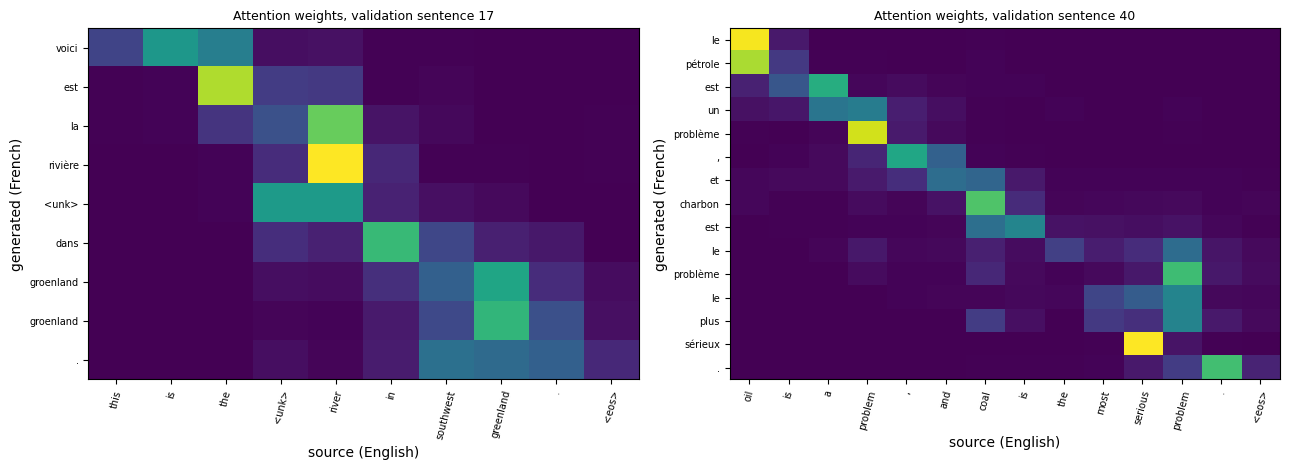

In [15]:
import matplotlib.pyplot as plt
import torch
@torch.no_grad()
def attn_map(model, src_row, max_len=40):
    model.eval()
    src = torch.tensor([src_row], dtype=torch.long, device=device); sl = torch.tensor([len(src_row)])
    enc_out, h, c = model.enc(src, sl); mask = src != PAD
    tok = torch.full((1,), SOS, dtype=torch.long, device=device); out_ids, ws = [], []
    for _ in range(max_len):
        out, h, c, w = model.dec(tok, h, c, enc_out, mask)
        tok = out.argmax(1)
        if tok.item() == EOS: break
        out_ids.append(tok.item()); ws.append(w[0].cpu().numpy())
    return out_ids, np.array(ws)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
for ax, i in zip(axes, (17, 40)):
    ids_out, W = attn_map(model_a, va_src[i])
    ax.imshow(W, aspect="auto", cmap="viridis")
    ax.set_xticks(range(len(va_src[i]))); ax.set_xticklabels([v_en.itos[t] for t in va_src[i]], rotation=75, fontsize=7)
    ax.set_yticks(range(len(ids_out))); ax.set_yticklabels([v_fr.itos[t] for t in ids_out], fontsize=7)
    ax.set_xlabel("source (English)"); ax.set_ylabel("generated (French)"); ax.set_title("Attention weights, validation sentence %d" % i, fontsize=9)
plt.tight_layout(); plt.savefig("/kaggle/working/s2_attention.png", dpi=150, bbox_inches="tight"); plt.show()